In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.stats import linregress, binned_statistic

In [5]:
path_in = '../data/'
path_output = '../figures/'


Gulf Stream
SWOT: N = 9077, slope = 19.11, r = 0.39
SWOT-like: N = 3923, slope = 27.11, r = 0.40

Agulhas
SWOT: N = 5315, slope = 32.52, r = 0.52
SWOT-like: N = 3939, slope = 46.33, r = 0.61

CCS
SWOT: N = 4193, slope = 52.76, r = 0.48
SWOT-like: N = 2280, slope = 109.86, r = 0.59

ACC1
SWOT: N = 7281, slope = 31.09, r = 0.49
SWOT-like: N = 3688, slope = 41.73, r = 0.55

ACC2
SWOT: N = 11115, slope = 11.13, r = 0.28
SWOT-like: N = 5128, slope = 51.44, r = 0.57

MED
SWOT: N = 5039, slope = 52.19, r = 0.53
SWOT-like: N = 4572, slope = 74.14, r = 0.63


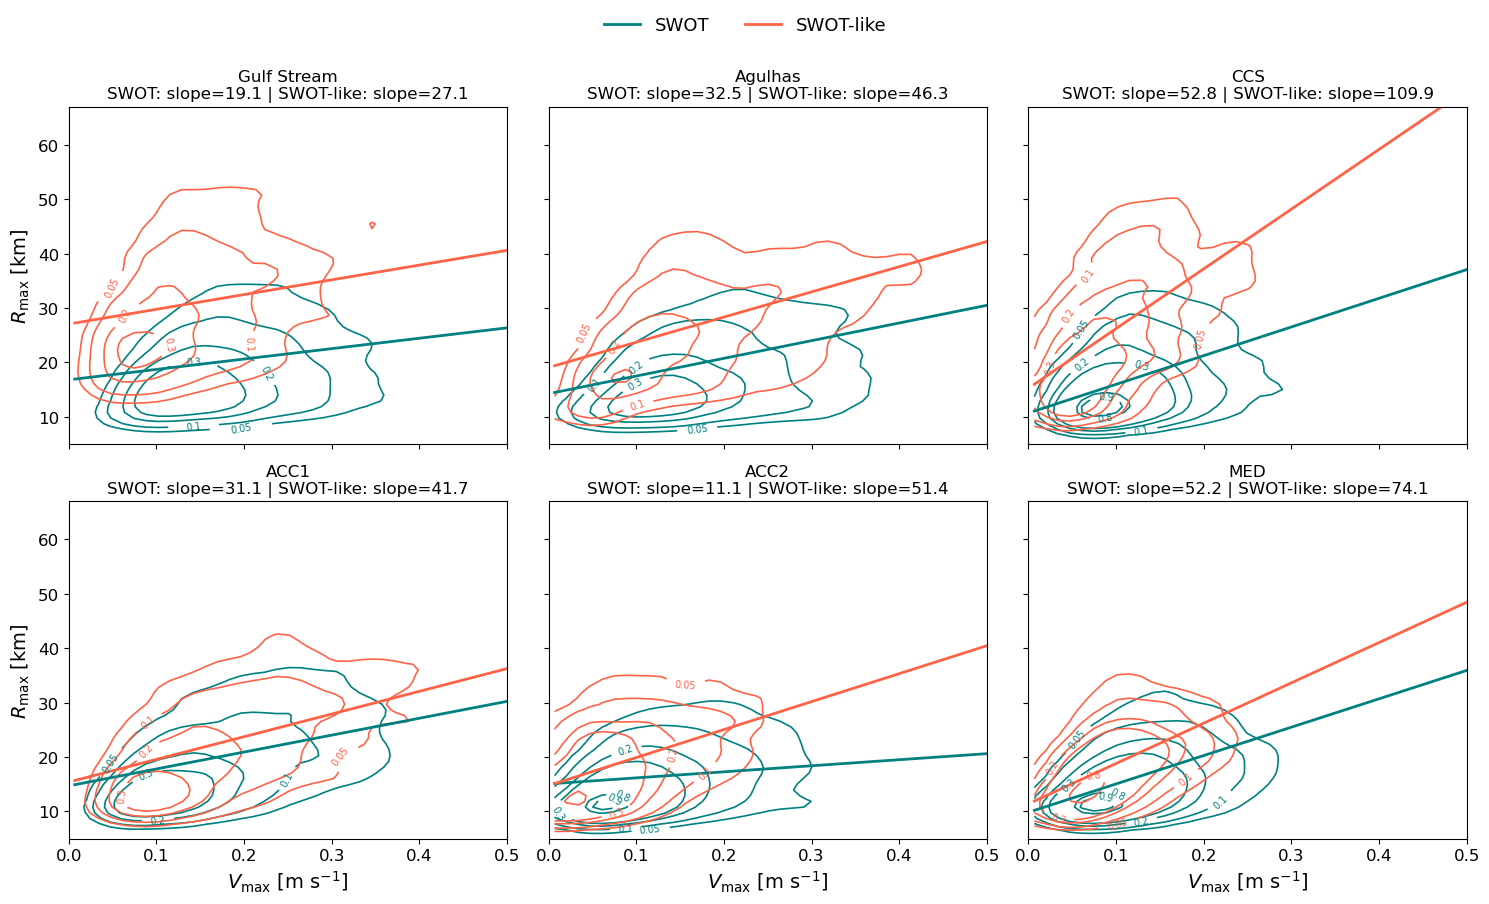

In [11]:
cases = ['GS2', 'AGULHAS', 'CCS', 'ACC1_bis', 'ACC2', 'MED']
case_titles = ['Gulf Stream', 'Agulhas', 'CCS', 'ACC1', 'ACC2', 'MED']

rmax_thr = 9  # km


######################
# COMMON HISTOGRAM BINS
######################

xbins = np.linspace(0, 0.8, 60)
ybins = np.linspace(5, 67, 60)

xcenters = 0.5 * (xbins[:-1] + xbins[1:])
ycenters = 0.5 * (ybins[:-1] + ybins[1:])

X, Y = np.meshgrid(xcenters, ycenters)


######################
# COMMON BINS FOR MEDIAN TREND
######################

xbins_trend = np.linspace(0, 0.8, 12)
xcenters_trend = 0.5 * (xbins_trend[:-1] + xbins_trend[1:])


######################
# CONTOUR LEVELS
######################

levels = [0.05, 0.1, 0.2, 0.3, 0.8, 0.9, 2]


######################
# FIGURE
######################

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
axes = axes.ravel()


for i, case in enumerate(cases):

    ax = axes[i]


    ######################
    # OPEN DATASETS
    ######################

    ds_swot0 = xr.open_dataset(f'{path_in}DYNED_SWOT_{case}_biharmonic_filtered.nc')
    ds_duacs0 = xr.open_dataset(f'{path_in}DYNED_{case}_SWOT_on_DUACS.nc')


    #######################
    # APPLY RMAX THRESHOLD
    #######################

    valid_swot = ds_swot0.r_max > rmax_thr
    ds_swot = ds_swot0.isel(obs=valid_swot)

    valid_duacs = ds_duacs0.r_max > rmax_thr
    ds_duacs = ds_duacs0.isel(obs=valid_duacs)


    #######################
    # SWOT DATA
    #######################

    vmax_swot = ds_swot.v_max.values
    rmax_swot = ds_swot.r_max.values

    mask_swot = np.isfinite(vmax_swot) & np.isfinite(rmax_swot)

    vmax_swot_mask = np.asarray(vmax_swot)[mask_swot]
    rmax_swot_mask = np.asarray(rmax_swot)[mask_swot]


    #######################
    # SWOT 2D HISTOGRAM
    #######################

    H_swot, _, _ = np.histogram2d(vmax_swot_mask, rmax_swot_mask, bins=[xbins, ybins])


    #######################
    # Percentage of observations per joint bin
    #######################

    H_swot = H_swot / H_swot.sum() * 100


    #######################
    # Gaussian smoothing
    #######################

    H_swot = gaussian_filter(H_swot, sigma=1.5)


    #######################
    # SWOT LINEAR REGRESSION
    #######################

    res_swot = linregress(vmax_swot_mask, rmax_swot_mask)
    yfit_swot = res_swot.intercept + res_swot.slope * xcenters


    #######################
    # SWOT BINNED MEDIAN
    #######################

    rmax_median_swot, _, _ = binned_statistic(vmax_swot_mask, rmax_swot_mask, statistic='median', bins=xbins_trend)


    #######################
    # DUACS DATA
    #######################

    vmax_duacs = ds_duacs.v_max.values
    rmax_duacs = ds_duacs.r_max.values

    mask_duacs = np.isfinite(vmax_duacs) & np.isfinite(rmax_duacs)

    vmax_duacs_mask = np.asarray(vmax_duacs)[mask_duacs]
    rmax_duacs_mask = np.asarray(rmax_duacs)[mask_duacs]


    #######################
    # DUACS 2D HISTOGRAM
    #######################

    H_duacs, _, _ = np.histogram2d(vmax_duacs_mask, rmax_duacs_mask, bins=[xbins, ybins])


    #######################
    # Percentage of observations per joint bin
    #######################

    H_duacs = H_duacs / H_duacs.sum() * 100


    #######################
    # Gaussian smoothing
    #######################

    H_duacs = gaussian_filter(H_duacs, sigma=1.5)


    #######################
    # DUACS LINEAR REGRESSION
    #######################

    res_duacs = linregress(vmax_duacs_mask, rmax_duacs_mask)
    yfit_duacs = res_duacs.intercept + res_duacs.slope * xcenters


    #######################
    # DUACS BINNED MEDIAN
    #######################

    rmax_median_duacs, _, _ = binned_statistic(vmax_duacs_mask, rmax_duacs_mask, statistic='median', bins=xbins_trend)


    #######################
    # PRINT STATISTICS
    #######################

    print('')
    print('========================================')
    print(case_titles[i])
    print('========================================')

    print(f'SWOT: N = {len(vmax_swot_mask)}, slope = {res_swot.slope:.2f}, r = {res_swot.rvalue:.2f}')
    print(f'SWOT-like: N = {len(vmax_duacs_mask)}, slope = {res_duacs.slope:.2f}, r = {res_duacs.rvalue:.2f}')


    #######################
    # PLOT CONTOURS
    #######################

    cs_swot = ax.contour(X, Y, H_swot.T, levels=levels, colors='teal', linewidths=1.2)
    ax.clabel(cs_swot, inline=True, fontsize=7, fmt='%g')

    cs_duacs = ax.contour(X, Y, H_duacs.T, levels=levels, colors='tomato', linewidths=1.2)
    ax.clabel(cs_duacs, inline=True, fontsize=7, fmt='%g')


    #######################
    # LINEAR REGRESSIONS
    #######################

    ax.plot(xcenters, yfit_swot, color='teal', lw=2, label='SWOT')
    ax.plot(xcenters, yfit_duacs, color='tomato', lw=2, label='SWOT-like')


    #######################
    # PANEL SETTINGS
    #######################

    ax.set_xlim(0, 0.5)
    ax.set_ylim(5, 67)
    ax.tick_params(axis='both', labelsize=12)

    ax.set_title(f'{case_titles[i]}\nSWOT: slope={res_swot.slope:.1f} | SWOT-like: slope={res_duacs.slope:.1f}', fontsize=12)


    #######################
    # CLOSE DATASETS
    #######################

    ds_swot0.close()
    ds_duacs0.close()


#######################
# AXIS LABELS
#######################

axes[0].set_ylabel(r'$R_{\max}$ [km]', fontsize=14)
axes[3].set_ylabel(r'$R_{\max}$ [km]', fontsize=14)

for ax in axes[3:]:
    ax.set_xlabel(r'$V_{\max}$ [m s$^{-1}$]', fontsize=14)


#######################
# LEGEND
#######################

handles = [
    plt.Line2D([0], [0], color='teal', lw=2),
    plt.Line2D([0], [0], color='tomato', lw=2)
]

labels = ['SWOT', 'SWOT-like']

fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=13, frameon=False, bbox_to_anchor=(0.5, 1.01))


#######################
# SAVE
#######################

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(path_output + 'Fig_S5.png', dpi=300, bbox_inches='tight')